/var/folders/3x/lgbz2mg13bj2r2hmg_vdp0qm0000gn/T/ipykernel_21835/526394499.py:64: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.cms.label(ax=ax, data=False, label="Simulation", rlabel="13.6 TeV (2026)")


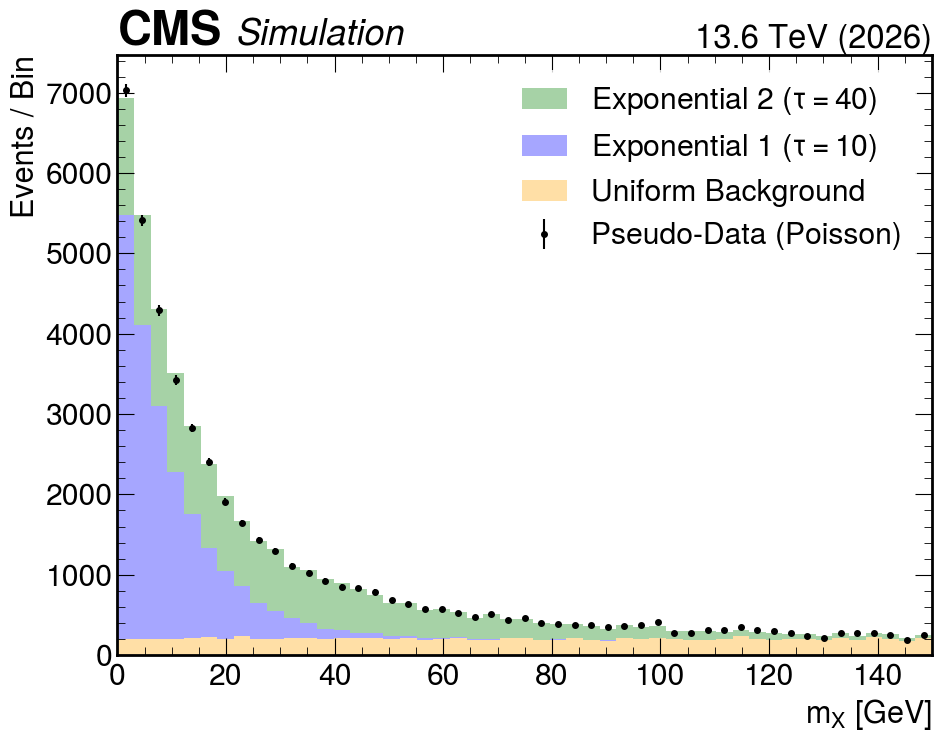

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# 1. Imposta lo stile CMS/HEP
plt.style.use(hep.style.CMS)

# 2. Generazione del dataset (2 Esponenziali + 1 Uniforme)
np.random.seed(42)  # Per riproducibilità
N_events = 50000

# Componente 1: Segnale/Fondo a corto raggio (Esponenziale ripido)
data_exp1 = np.random.exponential(scale=10, size=int(N_events * 0.4))
# Componente 2: Fondo a lungo raggio (Esponenziale più piatto)
data_exp2 = np.random.exponential(scale=40, size=int(N_events * 0.4))
# Componente 3: Fondo combinatorio/rumore (Uniforme)
data_uniform = np.random.uniform(low=0, high=150, size=int(N_events * 0.2))

# Combiniamo tutto in un unico dataset per calcolare i bin complessivi
all_data = np.concatenate([data_exp1, data_exp2, data_uniform])

# 3. Configurazione del binning dell'istogramma
bin_edges = np.linspace(0, 150, 50)

# 4. Creazione del grafico
fig, ax = plt.subplots(figsize=(10, 8))

# Calcoliamo gli istogrammi per ogni singola componente
counts_exp1, _ = np.histogram(data_exp1, bins=bin_edges)
counts_exp2, _ = np.histogram(data_exp2, bins=bin_edges)
counts_unif, _ = np.histogram(data_uniform, bins=bin_edges)

# Somma totale delle componenti
counts_total = counts_exp1 + counts_exp2 + counts_unif

# 5. Plotting in stile HEP
# Plottiamo le singole componenti come linee tratteggiate o continue pesate
hep.histplot(
    [counts_unif,counts_exp1, counts_exp2 ],
    bins=bin_edges,
    ax=ax,
    label=['Uniform Background' , r'Exponential 1 ($\tau=10$)', r'Exponential 2 ($\tau=40$)', ],
    color=['orange' , 'blue', 'green'],
    histtype='fill',
    alpha=0.35,
    stack=True
)

# Plottiamo la somma totale (di solito rappresentata come linea spessa o istogramma pieno/punti)
# hep.histplot(counts_total, bins=bin_edges, ax=ax, label='Total Sum', color='black', linewidth=2.5)

# Simulazione dei "Dati" sperimentali (punti con errore statistico poissoniano)
# Questo è molto comune nei plot di CMS per confrontare il modello (somma) con i dati stabili
data_obs = np.random.poisson(counts_total)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.errorbar(bin_centers, data_obs, yerr=np.sqrt(data_obs), fmt='ko', markersize=4, label='Pseudo-Data (Poisson)')

# 6. Decorazioni e Label in stile CMS
ax.set_xlabel('$m_{X}$ [GeV]', fontsize=22)
ax.set_ylabel('Events / Bin', fontsize=22)
ax.set_xlim(0, 150)

# Label ufficiali CMS (cambia "Simulation" in "Preliminary" o lascialo vuoto se necessario)
hep.cms.label(ax=ax, data=False, label="Simulation", rlabel="13.6 TeV (2026)")

# Legenda ben posizionata
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()